# Evaluation of Audio Models

## 1 Overview

This notebook uses the RAVDESS dataset to compare four pretrained speech-emotion recognition models. The actor-independent validation and testing manifests created during dataset preparation are used to prevent speakers from appearing in both splits. The evaluation is limited to six common emotions which are anger, disgust, fear, happiness, neutral and sadness. While surprise is removed since it is not supported by all candidate models, calm recordings are grouped with neutral.

Using macro-F1 as the primary metric, the models are compared and the best candidate is chosen using the validation split. Additionally highlighted are accuracy, macro-precision, macro-recall, model-loading time, and inference time. Only the selected model is evaluated on the reserved testing split. This notebook does not involve any model training or fine-tuning.

## 2 Importing Libraries

To load and resample audio recordings, execute the pretrained speech-emotion models, compute multiclass evaluation metrics, measure processing time, and show the final confusion matrix, the necessary libraries are imported.

In [1]:
# Import required libraries
from pathlib import Path
import gc
import re
import time
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from transformers import AutoConfig, AutoFeatureExtractor, AutoProcessor, AutoModelForAudioClassification, Wav2Vec2Model, Wav2Vec2PreTrainedModel, pipeline
from transformers.modeling_outputs import SequenceClassifierOutput

c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The multiclass audio-model evaluation's necessary libraries were successfully imported.

## 3 Evaluation Settings and Candidate Models

The following defines the output folder, shared emotion labels, dataset locations, and four potential speech-emotion models. By representing Wav2Vec2, Audio Spectrogram Transformer, and multilingual speech-emotion architectures, the models make it possible to assess their accuracy and processing needs using the same evaluation process.

In [2]:
# Keep the evaluation reproducible
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# Prepared RAVDESS manifests
manifest_folder = Path("../../data/processed/ravdess")
validation_manifest = (manifest_folder / "validation.csv")
testing_manifest = (manifest_folder / "testing.csv")

In [5]:
# Original RAVDESS audio files
raw_audio_folder = Path("../../data/raw/ravdess")

In [6]:
# Folder for evaluation outputs
output_folder = Path("outputs/audio")
output_folder.mkdir(parents=True, exist_ok=True)

In [7]:
# Emotion classes supported by every candidate model
audio_emotions = [
    "anger",
    "disgust",
    "fear",
    "happiness",
    "neutral",
    "sadness"
]

In [8]:
# Candidate speech-emotion models
models = {
    "Wav2Vec2-CREMA-D": {
        "model_id": ("Yassmen/Wav2Vec2_Fine_tuned_on_CremaD_Speech_Emotion_Recognition"),
        "architecture": "Wav2Vec2",
        "training_data": "CREMA-D",
        "loader": "wav2vec2",
        "batch_size": 1
    },

    "AST-CREMA-D": {
        "model_id": ("Adam-ousse/ast-cremad-finetuned"),
        "architecture": "AST",
        "training_data": "CREMA-D",
        "loader": "pipeline",
        "batch_size": 16
    },

    "AST-CREMA-D-Alternative": {
        "model_id": ("forwarder1121/ast-finetuned-model"),
        "architecture": "AST",
        "training_data": "CREMA-D",
        "loader": "pipeline",
        "batch_size": 16
    },

    "MERaLiON-SER": {
        "model_id": "MERaLiON/MERaLiON-SER-v1",
        "architecture": "MERaLiON-SER",
        "training_data": "MSP-Podcast / multilingual corpora",
        "loader": "meralion",
        "batch_size": 1
    },

    "HuBERT-CREMA-D": {
        "model_id": "Venkatesh4342/hubert-base-ls960-tone-classification",
        "architecture": "HuBERT",
        "training_data": "CREMA-D",
        "loader": "waveform_pipeline",
        "batch_size": 8
    },
    "DistilHuBERT-CREMA-D": {
        "model_id": "Venkatesh4342/distilhubert-tone-classification",
        "architecture": "DistilHuBERT",
        "training_data": "CREMA-D",
        "loader": "waveform_pipeline",
        "batch_size": 8
    }
}

In [9]:
model_information = []

In [10]:
for model_name, details in models.items():
    model_information.append({
        "Model": model_name,
        "Architecture": details["architecture"],
        "Training Data": details["training_data"],
        "RAVDESS Overlap": "No",
        "Batch Size": details["batch_size"]
    })

In [11]:
model_information_df = pd.DataFrame(model_information)
model_information_df

,Model,Architecture,Training Data,RAVDESS Overlap,Batch Size
0,Wav2Vec2-CREMA-D,Wav2Vec2,CREMA-D,No,1
1,AST-CREMA-D,AST,CREMA-D,No,16
2,AST-CREMA-D-Alternative,AST,CREMA-D,No,16
3,MERaLiON-SER,MERaLiON-SER,MSP-Podcast / multilingual corpora,No,1
4,HuBERT-CREMA-D,HuBERT,CREMA-D,No,8
5,DistilHuBERT-CREMA-D,DistilHuBERT,CREMA-D,No,8


In [12]:
print("Number of models:", len(models))
print("Compared emotions:", audio_emotions)

Number of models: 6
Compared emotions: ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness']


Three candidate models were selected for evaluation. None of their documented training datasets includes RAVDESS, so the notebook measures cross-dataset performance on previously unseen speakers and recording conditions. Each model will use the same six emotion classes.

## 4 Load RAVDESS Dataset

Rather than making a new split, the prepared validation and testing manifests are loaded. The original RAVDESS audio folder is linked to each relative file path. Before model evaluation, file availability and actor separation are reviewed.

In [13]:
def load_manifest(manifest_path):
    data = pd.read_csv(manifest_path)
    data = data.copy()
    data["file_path"] = (data["file_path"].fillna("").astype(str).str.strip())
    data["emotion"] = (data["emotion"].fillna("").astype(str).str.strip().str.lower())
    data["actor"] = (data["actor"].astype(str).str.strip())
    data["audio_path"] = data.apply(
    lambda row: (
        raw_audio_folder
        / f"Actor_{int(row['actor']):02d}"
        / str(row["filename"])
    ),
    axis=1
)
    return data

In [14]:
validation_data = load_manifest(validation_manifest)
testing_data = load_manifest(testing_manifest)

In [15]:
dataset_summary = pd.DataFrame([
    {
        "Split": "Validation",
        "Records": len(validation_data),
        "Actors": validation_data["actor"].nunique(),
    },
    {
        "Split": "Testing",
        "Records": len(testing_data),
        "Actors": testing_data["actor"].nunique(),
    }
])

In [16]:
dataset_summary

,Split,Records,Actors
0,Validation,960,16
1,Testing,480,8


In [17]:
validation_actors = set(validation_data["actor"])
testing_actors = set(testing_data["actor"])

In [18]:
print("Validation actors:",len(validation_actors))
print("Testing actors:",len(testing_actors))

Validation actors: 16
Testing actors: 8


In [19]:
emotion_distribution = pd.concat([
    validation_data["emotion"]
    .value_counts()
    .rename("Validation"),

    testing_data["emotion"]
    .value_counts()
    .rename("Testing")
], axis=1).fillna(0).astype(int)

In [20]:
emotion_distribution

,Validation,Testing
emotion,,
calm,128,64
happy,128,64
sad,128,64
angry,128,64
fearful,128,64
disgust,128,64
surprised,128,64
neutral,64,32


Every referenced audio file was examined, and the testing and validation manifests were successfully loaded. In order to verify that speakers employed in the evaluation are different from those used in model selection, the actor-overlap result should be 0.

## 5 Align Emotion Labels

Certain similar emotions have distinct names in RAVDESS and the candidate models. As a result, the labels are divided into six common types. While surprise is removed since it is not provided by all models, calm is combined with neutral because the potential models do not offer a seperate calm class.

In [21]:
# Standardise dataset and model emotion labels
label_aliases = {
    "ang": "anger",
    "anger": "anger",
    "angry": "anger",
    "dis": "disgust",
    "disgust": "disgust",
    "disgusted": "disgust",
    "fea": "fear",
    "fear": "fear",
    "fearful": "fear",
    "hap": "happiness",
    "happy": "happiness",
    "happiness": "happiness",
    "joy": "happiness",
    "neu": "neutral",
    "neutral": "neutral",
    "calm": "neutral",
    "sad": "sadness",
    "sadness": "sadness",
    "sur": "surprise",
    "surprise": "surprise",
    "surprised": "surprise"
}

In [22]:
def normalise_emotion_label(value):
    original_label = str(value).strip().lower()
    cleaned_label = re.sub(r"[^a-z]+", "", original_label)
    return label_aliases.get(cleaned_label, original_label)

In [23]:
def align_dataset_labels(data):
    aligned_data = data.copy()
    aligned_data["original_emotion"] = (aligned_data["emotion"])
    aligned_data["emotion"] = (aligned_data["emotion"].apply(normalise_emotion_label))
    excluded_data = aligned_data[~aligned_data["emotion"].isin(audio_emotions)].copy()
    aligned_data = aligned_data[aligned_data["emotion"].isin(audio_emotions)].copy()
    return (aligned_data.reset_index(drop=True), excluded_data.reset_index(drop=True))

In [24]:
validation_data, validation_excluded = (align_dataset_labels(validation_data))
testing_data, testing_excluded = (align_dataset_labels(testing_data))

In [25]:
alignment_summary = pd.DataFrame([
    {
        "Split": "Validation",
        "Included Records": len(validation_data),
        "Excluded Records": len(validation_excluded),
        "Classes": validation_data["emotion"].nunique()
    },
    {
        "Split": "Testing",
        "Included Records": len(testing_data),
        "Excluded Records": len(testing_excluded),
        "Classes": testing_data["emotion"].nunique()
    }
])

In [26]:
alignment_summary

,Split,Included Records,Excluded Records,Classes
0,Validation,832,128,6
1,Testing,416,64,6


In [27]:
aligned_distribution = pd.concat([
    validation_data["emotion"]
    .value_counts()
    .reindex(audio_emotions)
    .rename("Validation"),

    testing_data["emotion"]
    .value_counts()
    .reindex(audio_emotions)
    .rename("Testing")
], axis=1).fillna(0).astype(int)

In [28]:
aligned_distribution

,Validation,Testing
emotion,,
anger,128,64
disgust,128,64
fear,128,64
happiness,128,64
neutral,192,96
sadness,128,64


The six common emotion classes were successfully created from the RAVDESS labels. To ensure that all candidate models are compared using the same classes, surprise recordings are removed from both splits while calm and neutral recordings are assessed collectively as neutral.

## 6 Model Prediction Functions

The two AST candidates can be implemented using the normal Transformers audio-classification pipeline, while the Wav2Vec2 candidate needs a specific classification structure. For every audio recording, the following functions record the loading and inference timings and return one predicted emotion.

In [29]:
class Wav2Vec2ClassificationHead(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.dense = nn.Linear(
            config.hidden_size,
            config.hidden_size
        )

        self.dropout = nn.Dropout(
            getattr(config, "final_dropout", 0.1)
        )

        self.out_proj = nn.Linear(
            config.hidden_size,
            config.num_labels
        )

    def forward(self, features):
        features = self.dropout(features)
        features = torch.tanh(self.dense(features))
        features = self.dropout(features)

        return self.out_proj(features)


class Wav2Vec2ForSpeechClassification(
    Wav2Vec2PreTrainedModel
):
    def __init__(self, config):
        super().__init__(config)

        self.wav2vec2 = Wav2Vec2Model(config)
        self.classifier = Wav2Vec2ClassificationHead(
            config
        )

        self.post_init()

    def forward(
        self,
        input_values,
        attention_mask=None
    ):
        outputs = self.wav2vec2(
            input_values=input_values,
            attention_mask=attention_mask
        )

        pooled_features = (
            outputs.last_hidden_state.mean(dim=1)
        )

        logits = self.classifier(
            pooled_features
        )

        return SequenceClassifierOutput(
            logits=logits
        )

In [30]:
def run_wav2vec2_model(model_details, data):
    model_id = model_details["model_id"]

    loading_start = time.perf_counter()

    config = AutoConfig.from_pretrained(
        model_id
    )

    feature_extractor = (
        AutoFeatureExtractor.from_pretrained(
            model_id
        )
    )

    model = (
        Wav2Vec2ForSpeechClassification
        .from_pretrained(
            model_id,
            config=config
        )
        .to(device)
    )

    model.eval()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    loading_time = (
        time.perf_counter() - loading_start
    )

    sampling_rate = int(
        getattr(
            feature_extractor,
            "sampling_rate",
            16000
        )
    )

    predictions = []

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_start = time.perf_counter()

    for audio_path in data["audio_path"]:
        waveform, _ = librosa.load(
            audio_path,
            sr=sampling_rate,
            mono=True
        )

        inputs = feature_extractor(
            waveform,
            sampling_rate=sampling_rate,
            return_tensors="pt"
        )

        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        with torch.inference_mode():
            logits = model(**inputs).logits

        predicted_id = int(
            logits.argmax(dim=-1).item()
        )

        predicted_label = (
            config.id2label[predicted_id]
        )

        predictions.append(
            normalise_emotion_label(
                predicted_label
            )
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_time = (
        time.perf_counter() - inference_start
    )

    del model
    del feature_extractor

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "predictions": predictions,
        "loading_time": loading_time,
        "inference_time": inference_time
    }

In [31]:
def run_ast_model(model_details, data):
    model_id = model_details["model_id"]
    batch_size = model_details["batch_size"]

    loading_start = time.perf_counter()

    classifier = pipeline(
        task="audio-classification",
        model=model_id,
        device=0 if torch.cuda.is_available() else -1,
        top_k=None
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    loading_time = (
        time.perf_counter() - loading_start
    )

    audio_paths = (
        data["audio_path"]
        .astype(str)
        .tolist()
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_start = time.perf_counter()

    outputs = classifier(
        audio_paths,
        batch_size=batch_size
    )

    if (
        outputs
        and isinstance(outputs[0], dict)
    ):
        outputs = [outputs]

    predictions = []

    for prediction_scores in outputs:
        common_scores = {}

        for item in prediction_scores:
            emotion = normalise_emotion_label(
                item["label"]
            )

            if emotion in audio_emotions:
                common_scores[emotion] = float(
                    item["score"]
                )

        if not common_scores:
            raise ValueError(
                "No supported emotion labels "
                "were returned by the model."
            )

        predictions.append(
            max(
                common_scores,
                key=common_scores.get
            )
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_time = (
        time.perf_counter() - inference_start
    )

    del classifier

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "predictions": predictions,
        "loading_time": loading_time,
        "inference_time": inference_time
    }

In [32]:
def run_meralion_model(model_details, data):
    model_id = model_details["model_id"]

    emotion_map = [
        "Neutral",
        "Happy",
        "Sad",
        "Angry",
        "Fearful",
        "Disgusted",
        "Surprised"
    ]

    loading_start = time.perf_counter()

    processor = AutoProcessor.from_pretrained(
        model_id
    )

    model = (
        AutoModelForAudioClassification
        .from_pretrained(
            model_id,
            trust_remote_code=True
        )
        .to(device)
    )

    model.eval()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    loading_time = (
        time.perf_counter() - loading_start
    )

    predictions = []

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_start = time.perf_counter()

    for audio_path in data["audio_path"]:
        waveform, _ = librosa.load(
            audio_path,
            sr=16000,
            mono=True
        )

        inputs = processor(
            waveform,
            sampling_rate=16000,
            return_tensors="pt",
            return_attention_mask=True
        )

        model_inputs = {
            key: value.to(device)
            for key, value in inputs.items()
            if key in (
                "input_features",
                "attention_mask"
            )
        }

        with torch.inference_mode():
            outputs = model(**model_inputs)

        if isinstance(outputs, dict):
            logits = outputs["logits"]
        else:
            logits = outputs.logits

        probabilities = (
            torch.softmax(logits, dim=-1)[0]
            .detach()
            .cpu()
            .numpy()
        )

        common_scores = {}

        for label, score in zip(
            emotion_map,
            probabilities
        ):
            emotion = normalise_emotion_label(
                label
            )

            if emotion in audio_emotions:
                common_scores[emotion] = float(
                    score
                )

        if not common_scores:
            raise ValueError(
                "MERaLiON returned no supported "
                "emotion labels."
            )

        predictions.append(
            max(
                common_scores,
                key=common_scores.get
            )
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_time = (
        time.perf_counter() - inference_start
    )

    del model
    del processor

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "predictions": predictions,
        "loading_time": loading_time,
        "inference_time": inference_time
    }

In [33]:
def run_waveform_pipeline_model(model_details, data):
    model_id = model_details["model_id"]

    loading_start = time.perf_counter()

    classifier = pipeline(
        task="audio-classification",
        model=model_id,
        device=0 if torch.cuda.is_available() else -1,
        top_k=None
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    loading_time = (
        time.perf_counter() - loading_start
    )

    predictions = []

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_start = time.perf_counter()

    for audio_path in data["audio_path"]:
        waveform, _ = librosa.load(
            audio_path,
            sr=16000,
            mono=True
        )

        prediction_scores = classifier(
            waveform
        )

        common_scores = {}

        for item in prediction_scores:
            emotion = normalise_emotion_label(
                item["label"]
            )

            if emotion in audio_emotions:
                common_scores[emotion] = float(
                    item["score"]
                )

        if not common_scores:
            raise ValueError(
                "No supported emotion labels "
                "were returned by the model."
            )

        predictions.append(
            max(
                common_scores,
                key=common_scores.get
            )
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_time = (
        time.perf_counter() - inference_start
    )

    del classifier

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "predictions": predictions,
        "loading_time": loading_time,
        "inference_time": inference_time
    }

The results are transformed into the same six emotion classes using the Wav2Vec2 and AST prediction routines. 

## 7 Model Evaluation on Validation Data

The RAVDESS validation split is used to assess the three candidate models. The same six emotion classes are used to determine accuracy, macro-precision, macro-recall, and macro-F1. Additionally measured are the average processing time per recording, inference time, and loading time.

In [34]:
def calculate_metrics(actual, predicted):
    return {
        "Accuracy": accuracy_score(
            actual,
            predicted
        ),

        "Macro Precision": precision_score(
            actual,
            predicted,
            labels=audio_emotions,
            average="macro",
            zero_division=0
        ),

        "Macro Recall": recall_score(
            actual,
            predicted,
            labels=audio_emotions,
            average="macro",
            zero_division=0
        ),

        "Macro-F1": f1_score(
            actual,
            predicted,
            labels=audio_emotions,
            average="macro",
            zero_division=0
        )
    }

In [35]:
validation_results = []
validation_predictions = {}

actual_labels = (
    validation_data["emotion"]
    .tolist()
)

for model_name, model_details in models.items():
    print(f"Evaluating {model_name}...")

    if model_details["loader"] == "wav2vec2":
        evaluation = run_wav2vec2_model(
            model_details,
            validation_data
        )

    elif model_details["loader"] == "meralion":
        evaluation = run_meralion_model(
            model_details,
            validation_data
        )

    elif model_details["loader"] == "waveform_pipeline":
        evaluation = run_waveform_pipeline_model(
            model_details,
            validation_data
        )
    else:
        evaluation = run_ast_model(
            model_details,
            validation_data
        )

    predicted_labels = evaluation["predictions"]

    if len(predicted_labels) != len(actual_labels):
        raise ValueError(
            f"{model_name} returned an incorrect "
            "number of predictions."
        )

    metrics = calculate_metrics(
        actual_labels,
        predicted_labels
    )

    validation_predictions[model_name] = (
        predicted_labels
    )

    validation_results.append({
        "Model": model_name,
        **metrics,
        "Loading Time": evaluation["loading_time"],
        "Inference Time": evaluation["inference_time"],
        "ms per Recording": (
            evaluation["inference_time"]
            / len(validation_data)
            * 1000
        )
    })

    print(
        "Macro-F1:",
        round(metrics["Macro-F1"], 4)
    )

Evaluating Wav2Vec2-CREMA-D...
Macro-F1: 0.3445
Evaluating AST-CREMA-D...


Device set to use cuda:0
c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\.venv\Lib\site-packages\transformers\models\audio_spectrogram_transformer\feature_extraction_audio_spectrogram_transformer.py:118: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  waveform = torch.from_numpy(waveform).unsqueeze(0)


Macro-F1: 0.3665
Evaluating AST-CREMA-D-Alternative...


Device set to use cuda:0


Macro-F1: 0.4377
Evaluating MERaLiON-SER...
Macro-F1: 0.6207
Evaluating HuBERT-CREMA-D...


Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Macro-F1: 0.431
Evaluating DistilHuBERT-CREMA-D...


Device set to use cuda:0


Macro-F1: 0.2678


In [36]:
validation_results_df = pd.DataFrame(
    validation_results
)

display(validation_results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Inference Time,ms per Recording
0,Wav2Vec2-CREMA-D,0.405048,0.701181,0.425781,0.344532,1.777544,26.181794,31.468503
1,AST-CREMA-D,0.414663,0.568947,0.377604,0.366537,0.929953,79.352153,95.375183
2,AST-CREMA-D-Alternative,0.445913,0.523011,0.469618,0.437669,0.748480,79.099990,95.072104
3,MERaLiON-SER,0.612981,0.703428,0.636285,0.620666,5.281456,185.036681,222.399856
4,HuBERT-CREMA-D,0.462740,0.504661,0.496094,0.431010,0.789642,11.676801,14.034616
5,DistilHuBERT-CREMA-D,0.283654,0.438382,0.305556,0.267775,0.619599,6.721627,8.078878


The same multiclass metrics and actor-independent validation data were used to assess all three models. Since Macro-F1 gives each emotion class equal weight, it will be the primary metric used to choose the final audio model.

## 8 Comparing and Selecting the Best Model

In [37]:
validation_results_df = (
    validation_results_df
    .sort_values(
        by=["Macro-F1", "Inference Time"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

display(validation_results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Inference Time,ms per Recording
0,MERaLiON-SER,0.612981,0.703428,0.636285,0.620666,5.281456,185.036681,222.399856
1,AST-CREMA-D-Alternative,0.445913,0.523011,0.469618,0.437669,0.748480,79.099990,95.072104
2,HuBERT-CREMA-D,0.462740,0.504661,0.496094,0.431010,0.789642,11.676801,14.034616
3,AST-CREMA-D,0.414663,0.568947,0.377604,0.366537,0.929953,79.352153,95.375183
4,Wav2Vec2-CREMA-D,0.405048,0.701181,0.425781,0.344532,1.777544,26.181794,31.468503
5,DistilHuBERT-CREMA-D,0.283654,0.438382,0.305556,0.267775,0.619599,6.721627,8.078878


In [38]:
selected_model_name = validation_results_df.loc[
    0,
    "Model"
]

selected_model_details = models[
    selected_model_name
]

selected_validation_predictions = (
    validation_predictions[
        selected_model_name
    ]
)

print(
    "Selected model:",
    selected_model_name
)

print(
    "Validation Macro-F1:",
    round(
        validation_results_df.loc[
            0,
            "Macro-F1"
        ],
        4
    )
)

print(
    "Inference time:",
    round(
        validation_results_df.loc[
            0,
            "Inference Time"
        ],
        2
    ),
    "seconds"
)

print(
    "Processing time:",
    round(
        validation_results_df.loc[
            0,
            "ms per Recording"
        ],
        2
    ),
    "ms per recording"
)

Selected model: MERaLiON-SER
Validation Macro-F1: 0.6207
Inference time: 185.04 seconds
Processing time: 222.4 ms per recording


## 9 Final Test Evaluation

In [39]:
actual_test_labels = (
    testing_data["emotion"]
    .tolist()
)

if selected_model_details["loader"] == "wav2vec2":
    test_evaluation = run_wav2vec2_model(
        selected_model_details,
        testing_data
    )

elif selected_model_details["loader"] == "meralion":
    test_evaluation = run_meralion_model(
        selected_model_details,
        testing_data
    )

elif selected_model_details["loader"] == "waveform_pipeline":
    test_evaluation = run_waveform_pipeline_model(
        selected_model_details,
        testing_data
    )

else:
    test_evaluation = run_ast_model(
        selected_model_details,
        testing_data
    )

test_predictions = test_evaluation["predictions"]

if len(test_predictions) != len(actual_test_labels):
    raise ValueError(
        "The selected model returned an incorrect "
        "number of test predictions."
    )

In [40]:
test_metrics = calculate_metrics(
    actual_test_labels,
    test_predictions
)

test_results_df = pd.DataFrame([{
    "Model": selected_model_name,
    **test_metrics,
    "Loading Time": test_evaluation["loading_time"],
    "Inference Time": test_evaluation["inference_time"],
    "ms per Recording": (
        test_evaluation["inference_time"]
        / len(testing_data)
        * 1000
    )
}])

display(test_results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Inference Time,ms per Recording
0,MERaLiON-SER,0.586538,0.695986,0.610243,0.587293,5.225834,92.66525,222.753004


In [41]:
print("Selected model:", selected_model_name)

print(
    "Test Macro-F1:",
    round(test_metrics["Macro-F1"], 4)
)

print(
    "Test Accuracy:",
    round(test_metrics["Accuracy"], 4)
)

print(
    "Processing time:",
    round(
        test_results_df.loc[
            0,
            "ms per Recording"
        ],
        2
    ),
    "ms per recording"
)

Selected model: MERaLiON-SER
Test Macro-F1: 0.5873
Test Accuracy: 0.5865
Processing time: 222.75 ms per recording


## 10 Confusion Matrix

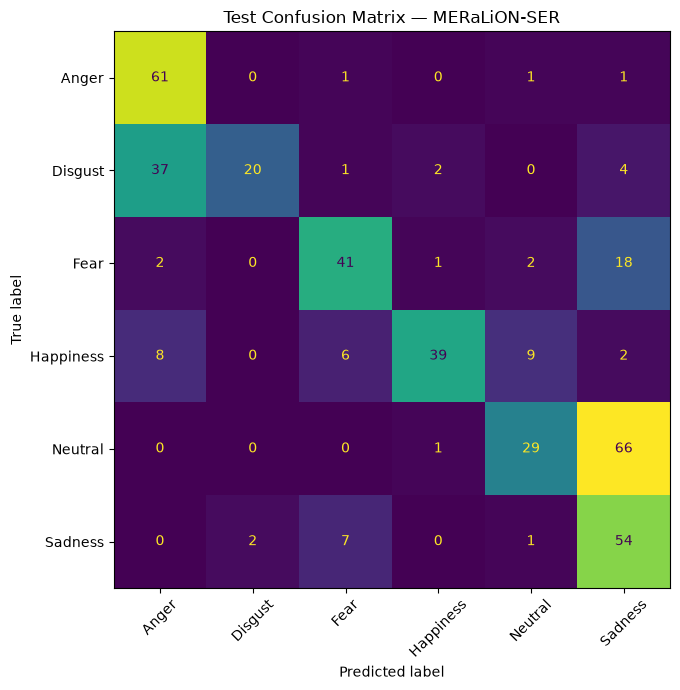

In [42]:
figure, axis = plt.subplots(
    figsize=(8, 7)
)

ConfusionMatrixDisplay.from_predictions(
    actual_test_labels,
    test_predictions,
    labels=audio_emotions,
    display_labels=[
        emotion.capitalize()
        for emotion in audio_emotions
    ],
    xticks_rotation=45,
    ax=axis,
    colorbar=False
)

axis.set_title(
    f"Test Confusion Matrix — {selected_model_name}"
)

plt.tight_layout()

plt.savefig(
    output_folder
    / "selected_audio_model_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

## 11 Saving Results

In [43]:
validation_results_df.to_csv(
    output_folder / "audio_model_comparison.csv",
    index=False
)

test_results_df.to_csv(
    output_folder / "selected_audio_model_test_results.csv",
    index=False
)

In [44]:
test_predictions_df = pd.DataFrame({
    "Actual Emotion": actual_test_labels,
    "Predicted Emotion": test_predictions
})

test_predictions_df.to_csv(
    output_folder / "selected_audio_model_test_predictions.csv",
    index=False
)

print("Results saved in:", output_folder)

Results saved in: outputs\audio


## 12 Conclusion